# Kindle Hybrid Recommender: unified inference, fusion and evaluation

This notebook combines the final **content-based**, **collaborative filtering** and
**GRU4Rec sequential** models into one reproducible hybrid-recommendation workflow.

It does not retrain the large component models. Instead, it loads their saved assets,
generates candidate-level scores under one shared protocol, then evaluates individual
and hybrid models fairly.

## Implemented hybrid strategies

1. **Adaptive weighted fusion**: combines normalised content, CF and sequential scores;
   weights are selected on validation data and can vary by history length.
2. **Cascade retrieval + sequential re-ranking**: content and CF retrieve a candidate
   pool, then GRU4Rec re-ranks that pool.
3. **Optional switching hybrid**: a lifecycle-style fallback policy for sparse users.

## Important scope

The final content model artifact was not copied into this repository, but its complete
candidate-level validation and test scores were saved in
`Content_Based/content_based_candidate_scores.csv.gz`. Therefore this notebook can run
the fully reproducible **offline hybrid experiment** immediately. Dynamic full-catalogue
content scoring requires the missing content vectorizer/embedding artifact; this is
reported explicitly in the final audit cell.

## 1. Environment and paths

The notebook automatically uses GPU in Colab when available, but all inference code is
also valid on CPU. GPU is recommended because generating GRU4Rec scores for about 13
million user-candidate pairs can take several minutes on CPU.

Run this notebook from the project root after copying the whole project to Colab. Edit
only the path candidates below if your Drive layout differs.

In [71]:
from __future__ import annotations

import gzip
import json
import math
import random
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None

SEED = 2026
TOP_K = 10
SCORE_BATCH_USERS = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd()
DATA_DIR_CANDIDATES = [
    PROJECT_ROOT / "dataset" / "processed_kindle",
    PROJECT_ROOT / "processed_kindle",
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.is_dir()), None)
CONTENT_SCORE_PATH = PROJECT_ROOT / "Content_Based" / "content_based_candidate_scores.csv.gz"
CF_CHECKPOINT = PROJECT_ROOT / "models" / "collaborative_model.pt"
GRU_CHECKPOINT = PROJECT_ROOT / "models" / "gru4rec_best.pt"
OUTPUT_DIR = PROJECT_ROOT / "hybrid_results"
OUTPUT_DIR.mkdir(exist_ok=True)

assert DATA_DIR is not None, f"Cannot find processed_kindle under {PROJECT_ROOT.resolve()}"
assert CONTENT_SCORE_PATH.exists(), f"Missing {CONTENT_SCORE_PATH}"
assert CF_CHECKPOINT.exists(), f"Missing {CF_CHECKPOINT}"
assert GRU_CHECKPOINT.exists(), f"Missing {GRU_CHECKPOINT}"

print("project root:", PROJECT_ROOT.resolve())
print("data directory:", DATA_DIR.resolve())
print("device:", DEVICE)

project root: /Users/weisi/Desktop/unsw/9727/project
data directory: /Users/weisi/Desktop/unsw/9727/project/processed_kindle
device: cpu


## 2. Load shared data and audit the evaluation protocol

Every model is evaluated on exactly the same candidate set: one held-out positive book
and 100 pre-generated negatives per user. Validation uses only training history; test
uses training history plus the validation interaction. This is the common protocol used
by the content and sequential notebooks.

In [72]:
def parse_item_sequence(value: str) -> list[int]:
    if pd.isna(value) or not str(value).strip():
        return []
    return [int(x) for x in str(value).split()]

train_sequences_df = pd.read_csv(DATA_DIR / "train_sequences.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
item_metadata = pd.read_csv(DATA_DIR / "item_metadata.csv")
interactions = pd.read_csv(DATA_DIR / "interactions_clean.csv")

train_sequences = dict(zip(
    train_sequences_df.user_idx.astype(int),
    train_sequences_df.item_seq.map(parse_item_sequence),
))
val_targets = dict(zip(val_df.user_idx.astype(int), val_df.pos_idx.astype(int)))
test_targets = dict(zip(test_df.user_idx.astype(int), test_df.pos_idx.astype(int)))

with open(DATA_DIR / "preprocess_stats.json", encoding="utf-8") as f:
    preprocess_stats = json.load(f)

USER_COUNT = len(train_sequences)
ITEM_COUNT = int(item_metadata.item_idx.max()) + 1
assert set(train_sequences) == set(val_targets) == set(test_targets)
assert USER_COUNT == preprocess_stats["num_users"]
assert ITEM_COUNT == preprocess_stats["num_items"]

train_popularity = np.bincount(
    interactions.loc[interactions["split"] == "train", "item_idx"].to_numpy(),
    minlength=ITEM_COUNT,
).astype(np.float32)
popularity_scores = np.log1p(train_popularity)

test_contexts = {
    user: train_sequences[user] + [val_targets[user]]
    for user in train_sequences
}

print(f"users={USER_COUNT:,}; items={ITEM_COUNT:,}")
print(f"train interactions={preprocess_stats['num_train_interactions']:,}")
print("protocol: validation=train history; test=train history + validation target")

users=64,867; items=81,322
train interactions=884,136
protocol: validation=train history; test=train history + validation target


## 3. Load the canonical content-model candidate scores

The content notebook selected **Weighted-TFIDF-TUNED** using validation NDCG@10 and
exported a score for every official candidate. This file is used as the canonical
candidate ordering for all models, so it prevents the previous collaborative-filtering
candidate-set mismatch (where a negative was accidentally treated as a positive).

In [73]:
def load_canonical_split(split: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return users, candidates, content scores and positive-at-column-zero labels."""
    frame = pd.read_csv(
        CONTENT_SCORE_PATH,
        compression="gzip",
        usecols=["user_idx", "item_idx", "split", "score", "is_positive"],
    )
    frame = frame.loc[frame["split"] == split].copy()
    frame.sort_values(["user_idx"], kind="stable", inplace=True)
    group_sizes = frame.groupby("user_idx", sort=True).size()
    assert len(group_sizes) == USER_COUNT and group_sizes.eq(101).all(), "Expected 101 candidates/user"

    users = group_sizes.index.to_numpy(dtype=np.int64)
    candidates = frame.item_idx.to_numpy(dtype=np.int64).reshape(-1, 101)
    scores = frame.score.to_numpy(dtype=np.float32).reshape(-1, 101)
    positives = frame.is_positive.astype(bool).to_numpy().reshape(-1, 101)
    assert positives[:, 0].all() and positives.sum() == len(users), "Positive must be first candidate"
    return users, candidates, scores, positives

val_users, val_candidates, val_content_scores, val_positive_mask = load_canonical_split("validation")
test_users, test_candidates, test_content_scores, test_positive_mask = load_canonical_split("test")

assert np.array_equal(val_users, test_users)
assert np.array_equal(val_candidates[:, 0], np.array([val_targets[u] for u in val_users]))
assert np.array_equal(test_candidates[:, 0], np.array([test_targets[u] for u in test_users]))

print("canonical score file verified")
print("validation matrix:", val_candidates.shape, "test matrix:", test_candidates.shape)

canonical score file verified
validation matrix: (64867, 101) test matrix: (64867, 101)


## 4. Recreate the two saved PyTorch inference models

The collaborative checkpoint stores only embedding weights, so the small Two-Tower
architecture is reconstructed here. The sequential checkpoint stores its GRU4Rec
configuration and state dictionary. No training is performed in this notebook.

In [74]:
class TwoTowerInference(nn.Module):
    """Matches the final CF notebook when use_mlp_layers=False."""
    def __init__(self, n_users: int, n_items: int, embedding_dim: int):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

    def score_candidates(self, users: torch.Tensor, candidates: torch.Tensor) -> torch.Tensor:
        user_vec = F.normalize(self.user_embedding(users), p=2, dim=1)
        item_vec = F.normalize(self.item_embedding(candidates), p=2, dim=2)
        return torch.einsum("bd,bcd->bc", user_vec, item_vec)


class GRU4RecInference(nn.Module):
    """Architecture matched to SASRec_Sequential_Recommender.ipynb."""
    def __init__(self, num_items: int, max_len: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.max_len = max_len
        self.item_embedding = nn.Embedding(num_items + 1, hidden_dim, padding_idx=0)
        self.gru = nn.GRU(
            hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, item_ids: torch.Tensor) -> torch.Tensor:
        lengths = item_ids.ne(0).sum(dim=1).clamp_min(1).cpu()
        embedded = self.dropout(self.item_embedding(item_ids))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        packed_outputs, _ = self.gru(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs, batch_first=True, total_length=self.max_len
        )
        return self.dropout(output)

    def score_candidates(self, item_ids: torch.Tensor, candidate_ids: torch.Tensor) -> torch.Tensor:
        features = self(item_ids)
        final_pos = item_ids.ne(0).sum(dim=1).clamp_min(1).sub(1)
        context = features[torch.arange(item_ids.size(0), device=item_ids.device), final_pos]
        return torch.einsum("bd,bcd->bc", context, self.item_embedding(candidate_ids))


def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:  # compatibility with older PyTorch versions
        return torch.load(path, map_location="cpu")


cf_state = safe_torch_load(CF_CHECKPOINT)
cf_user_shape = cf_state["usermodel.model.weight"].shape
cf_item_shape = cf_state["itemmodel.model.weight"].shape
assert cf_user_shape[0] == USER_COUNT and cf_item_shape[0] == ITEM_COUNT
assert cf_user_shape[1] == cf_item_shape[1]

cf_model = TwoTowerInference(USER_COUNT, ITEM_COUNT, cf_user_shape[1])
cf_model.user_embedding.weight.data.copy_(cf_state["usermodel.model.weight"])
cf_model.item_embedding.weight.data.copy_(cf_state["itemmodel.model.weight"])
cf_model = cf_model.to(DEVICE).eval()

gru_checkpoint = safe_torch_load(GRU_CHECKPOINT)
gru_config = gru_checkpoint["config"]
assert gru_checkpoint["num_items"] == ITEM_COUNT
assert gru_checkpoint.get("raw_to_model_item_offset", 1) == 1
gru_model = GRU4RecInference(
    num_items=ITEM_COUNT,
    max_len=int(gru_config["max_len"]),
    hidden_dim=int(gru_config["hidden_dim"]),
    num_layers=int(gru_config["num_layers"]),
    dropout=float(gru_config["dropout"]),
)
gru_model.load_state_dict(gru_checkpoint["model_state_dict"])
gru_model = gru_model.to(DEVICE).eval()

print("CF embedding dimension:", cf_user_shape[1])
print("GRU4Rec config:", {k: gru_config[k] for k in ["name", "max_len", "hidden_dim", "num_layers", "dropout"]})

CF embedding dimension: 128
GRU4Rec config: {'name': 'GRU4Rec-short-20', 'max_len': 20, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.1}


## 5. Generate or reuse aligned CF and GRU4Rec candidate scores

Both saved models score the **same 101 candidates in the same order** as the content
file. Cached `.npy` arrays make repeated fusion experiments fast. Delete the cache files
in `hybrid_results/` only if a component checkpoint changes.

In [75]:
def right_pad_context(history: list[int], max_len: int) -> np.ndarray:
    history = list(history)[-max_len:]
    padded = np.zeros(max_len, dtype=np.int64)
    if history:
        padded[:len(history)] = np.asarray(history, dtype=np.int64) + 1
    return padded


@torch.no_grad()
def score_cf(users: np.ndarray, candidates: np.ndarray) -> np.ndarray:
    blocks = []
    for start in range(0, len(users), SCORE_BATCH_USERS):
        end = start + SCORE_BATCH_USERS
        u = torch.as_tensor(users[start:end], dtype=torch.long, device=DEVICE)
        c = torch.as_tensor(candidates[start:end], dtype=torch.long, device=DEVICE)
        blocks.append(cf_model.score_candidates(u, c).cpu().numpy().astype(np.float32))
    return np.vstack(blocks)


@torch.no_grad()
def score_gru(users: np.ndarray, candidates: np.ndarray, contexts: dict[int, list[int]]) -> np.ndarray:
    blocks = []
    max_len = int(gru_config["max_len"])
    for start in range(0, len(users), SCORE_BATCH_USERS):
        end = start + SCORE_BATCH_USERS
        histories = np.stack([right_pad_context(contexts[int(u)], max_len) for u in users[start:end]])
        # Model IDs reserve zero for padding, hence raw item index + 1.
        c = candidates[start:end] + 1
        history_tensor = torch.as_tensor(histories, dtype=torch.long, device=DEVICE)
        candidate_tensor = torch.as_tensor(c, dtype=torch.long, device=DEVICE)
        blocks.append(gru_model.score_candidates(history_tensor, candidate_tensor).cpu().numpy().astype(np.float32))
    return np.vstack(blocks)


def load_or_generate_scores(name: str, split: str, scorer, users, candidates, contexts=None) -> np.ndarray:
    path = OUTPUT_DIR / f"{name}_{split}_candidate_scores.npy"
    if path.exists():
        scores = np.load(path)
        assert scores.shape == candidates.shape
        print(f"loaded cached {path.name}")
        return scores
    started = time.time()
    scores = scorer(users, candidates) if contexts is None else scorer(users, candidates, contexts)
    np.save(path, scores)
    print(f"generated {path.name} in {time.time() - started:.1f}s")
    return scores


val_cf_scores = load_or_generate_scores("cf", "validation", score_cf, val_users, val_candidates)
test_cf_scores = load_or_generate_scores("cf", "test", score_cf, test_users, test_candidates)
val_gru_scores = load_or_generate_scores("gru4rec", "validation", score_gru, val_users, val_candidates, train_sequences)
test_gru_scores = load_or_generate_scores("gru4rec", "test", score_gru, test_users, test_candidates, test_contexts)

loaded cached cf_validation_candidate_scores.npy
loaded cached cf_test_candidate_scores.npy
loaded cached gru4rec_validation_candidate_scores.npy
loaded cached gru4rec_test_candidate_scores.npy


## 6. Shared ranking metrics and catalogue diagnostics

The positive book is stored in candidate column zero. Scores are converted to a rank for
each user, then aggregated into Recall/Hit@10, Precision@10, NDCG@10 and MRR. Catalogue
metrics are computed from each model's Top-10 test recommendations.

In [76]:
def ranks_from_scores(scores: np.ndarray) -> np.ndarray:
    """Positive is column zero; stable sorting resolves exact ties reproducibly."""
    order = np.argsort(-scores, axis=1, kind="stable")
    return np.argmax(order == 0, axis=1) + 1


def ranking_metrics(scores: np.ndarray, k: int = TOP_K) -> dict[str, float]:
    ranks = ranks_from_scores(scores)
    hits = ranks <= k
    return {
        f"Hit@{k}": float(hits.mean()),
        f"Recall@{k}": float(hits.mean()),
        f"Precision@{k}": float(hits.mean() / k),
        f"NDCG@{k}": float(np.where(hits, 1.0 / np.log2(ranks + 1), 0.0).mean()),
        "MRR": float((1.0 / ranks).mean()),
        "users": int(len(ranks)),
    }


item_categories = {
    int(row.item_idx): frozenset(x.strip() for x in str(row.categories).split(";") if x.strip())
    for row in item_metadata.itertuples()
}


def catalogue_metrics_fn(scores: np.ndarray, candidates: np.ndarray, k: int = TOP_K) -> dict[str, float]:
    top_positions = np.argsort(-scores, axis=1, kind="stable")[:, :k]
    top_items = np.take_along_axis(candidates, top_positions, axis=1)
    flat_items = top_items.ravel()
    total = float(train_popularity.sum() + ITEM_COUNT)
    max_novelty = max(float(np.log2(total)), 1e-8)
    item_novelty = -np.log2((train_popularity[flat_items] + 1.0) / total) / max_novelty
    novelty = float(np.mean(item_novelty))
    diversities = []
    for row in top_items:
        pair_sims = []
        for i in range(len(row)):
            for j in range(i + 1, len(row)):
                left, right = item_categories.get(int(row[i]), frozenset()), item_categories.get(int(row[j]), frozenset())
                pair_sims.append(len(left & right) / max(len(left | right), 1))
        diversities.append(1.0 - np.mean(pair_sims) if pair_sims else 0.0)
    return {
        "CatalogueCoverage": float(len(np.unique(flat_items)) / ITEM_COUNT),
        "Novelty": novelty,
        "IntraListDiversity": float(np.mean(diversities)),
    }


def evaluate_model(name: str, validation_scores: np.ndarray, test_scores: np.ndarray) -> list[dict]:
    rows = []
    for split, scores, candidates in [
        ("validation", validation_scores, val_candidates),
        ("test", test_scores, test_candidates),
    ]:
        rows.append({"model": name, "split": split, **ranking_metrics(scores), **catalogue_metrics_fn(scores, candidates)})
    return rows

## 7. Evaluate the individual models

Before fusion, re-evaluate content, CF and GRU4Rec under one implementation and one
candidate protocol. A popularity baseline is also included to make gains interpretable.

In [77]:
val_popularity_scores = popularity_scores[val_candidates]
test_popularity_scores = popularity_scores[test_candidates]

results = []
results += evaluate_model("Popularity", val_popularity_scores, test_popularity_scores)
results += evaluate_model("Content: Weighted-TFIDF", val_content_scores, test_content_scores)
results += evaluate_model("Collaborative Filtering: Two-Tower", val_cf_scores, test_cf_scores)
results += evaluate_model("Sequential: GRU4Rec", val_gru_scores, test_gru_scores)

single_model_results = pd.DataFrame(results)
display(single_model_results.sort_values(["split", f"NDCG@{TOP_K}"], ascending=[True, False]))

,model,split,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
5,Collaborative Filtering: Two-Tower,test,0.748902,0.748902,0.074890,0.534441,0.478403,64867,0.985969,0.828852,0.673156
3,Content: Weighted-TFIDF,test,0.591441,0.591441,0.059144,0.428251,0.393531,64867,0.818315,0.827954,0.547997
7,Sequential: GRU4Rec,test,0.640726,0.640726,0.064073,0.423703,0.371448,64867,0.832739,0.796190,0.679505
1,Popularity,test,0.381195,0.381195,0.038120,0.235453,0.209538,64867,0.181611,0.738379,0.676371
4,Collaborative Filtering: Two-Tower,validation,0.803644,0.803644,0.080364,0.598337,0.542811,64867,0.986301,0.828034,0.671941
6,Sequential: GRU4Rec,validation,0.677741,0.677741,0.067774,0.455494,0.400256,64867,0.833895,0.794384,0.682704
2,Content: Weighted-TFIDF,validation,0.593152,0.593152,0.059315,0.434093,0.400600,64867,0.833587,0.827872,0.552901
0,Popularity,validation,0.412567,0.412567,0.041257,0.256567,0.227543,64867,0.181845,0.738126,0.676716


## 8. Hybrid 1: adaptive weighted score fusion

This section optimises the weighted fusion strategy used to combine the prediction scores from the Content-Based, Collaborative Filtering, and GRU recommendation models. Since the three models produce scores with different numerical distributions, **z-score normalisation** is first applied independently to each model to standardise the scores and ensure that they are directly comparable before fusion.

The final recommendation score is computed as a weighted combination of the normalised prediction scores. To identify the most effective weight configuration, a two-stage grid search is performed on the validation set using **NDCG@10** as the optimisation objective. A coarse search is first conducted over the entire weight space with a step size of 0.1 to locate a promising region. A finer search with a step size of 0.01 is then carried out around the best coarse solution to obtain a more precise set of fusion weights.

The optimal weight combination selected from the fine search is used as the final Adaptive Weighted fusion model for subsequent evaluation and comparison with the other recommendation approaches.

In [78]:
def z_normalise(scores: np.ndarray) -> np.ndarray:
    mean = scores.mean(axis=1, keepdims=True)
    std = scores.std(axis=1, keepdims=True)
    return (scores - mean) / np.maximum(std, 1e-8)


def weighted_fusion(content: np.ndarray, cf: np.ndarray, gru: np.ndarray, weights: tuple[float, float, float]) -> np.ndarray:
    wc, wf, ws = weights
    return wc * z_normalise(content) + wf * z_normalise(cf) + ws * z_normalise(gru)


coarse_results = []
coarse_grid = np.arange(0.0, 1.01, 0.1)
for wc in coarse_grid:
    for wf in coarse_grid:
        ws = round(1.0 - wc - wf, 10)
        if ws < 0:
            continue
        weights = (float(wc), float(wf), float(ws))
        metrics = ranking_metrics(weighted_fusion(val_content_scores, val_cf_scores, val_gru_scores, weights))

        coarse_results.append({"content_weight": wc, "cf_weight": wf, "gru_weight": ws, **metrics})

coarse_search = (pd.DataFrame(coarse_results).sort_values(f"NDCG@{TOP_K}", ascending=False).reset_index(drop=True))
coarse_best = tuple(coarse_search.loc[0,["content_weight", "cf_weight", "gru_weight"]].astype(float))
print("Coarse best weights:", coarse_best)
display(coarse_search.head())


best_wc, best_wf, _ = coarse_best
fine_results = []
wc_range = np.arange( max(0, best_wc - 0.1), min(1, best_wc + 0.1) + 0.001,0.01,)
wf_range = np.arange(max(0, best_wf - 0.1),min(1, best_wf + 0.1) + 0.001,0.01,)

for wc in wc_range:
    for wf in wf_range:
        ws = round(1.0 - wc - wf, 10)
        if ws < 0 or ws > 1:
            continue

        weights = (round(float(wc), 2), round(float(wf), 2), round(float(ws), 2),)
        metrics = ranking_metrics( weighted_fusion( val_content_scores, val_cf_scores, val_gru_scores, weights))
        fine_results.append({"content_weight": weights[0], "cf_weight": weights[1], "gru_weight": weights[2],**metrics})

fine_search = (pd.DataFrame(fine_results).sort_values(f"NDCG@{TOP_K}", ascending=False).reset_index(drop=True))
best_weights = tuple(fine_search.loc[0,["content_weight", "cf_weight", "gru_weight"]].astype(float))

print("Final best weights:", best_weights)
display(fine_search.head(10))

Coarse best weights: (0.2, 0.4, 0.4)


,content_weight,cf_weight,gru_weight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,0.2,0.4,0.4,0.847503,0.847503,0.084750,0.658924,0.606816,64867
1,0.2,0.5,0.3,0.848305,0.848305,0.084830,0.656599,0.603521,64867
2,0.3,0.4,0.3,0.844297,0.844297,0.084430,0.653322,0.600716,64867
3,0.2,0.3,0.5,0.837992,0.837992,0.083799,0.653216,0.602604,64867
4,0.1,0.5,0.4,0.844975,0.844975,0.084498,0.653214,0.600223,64867


Final best weights: (0.19, 0.42, 0.39)


,content_weight,cf_weight,gru_weight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,0.19,0.42,0.39,0.847920,0.847920,0.084792,0.659047,0.606835,64867
1,0.18,0.44,0.38,0.848367,0.848367,0.084837,0.659022,0.606636,64867
2,0.20,0.41,0.39,0.847658,0.847658,0.084766,0.659000,0.606874,64867
3,0.20,0.42,0.38,0.848274,0.848274,0.084827,0.658969,0.606616,64867
4,0.19,0.43,0.38,0.848228,0.848228,0.084823,0.658962,0.606617,64867
5,0.18,0.45,0.37,0.848875,0.848875,0.084888,0.658934,0.606352,64867
6,0.20,0.39,0.41,0.847149,0.847149,0.084715,0.658931,0.606948,64867
7,0.20,0.40,0.40,0.847503,0.847503,0.084750,0.658924,0.606816,64867
8,0.20,0.43,0.37,0.848598,0.848598,0.084860,0.658915,0.606432,64867
9,0.21,0.41,0.38,0.847966,0.847966,0.084797,0.658912,0.606659,64867


## 9. Hybrid 2: cascade retrieval and sequential re-ranking

This hybrid recommendation model adopts a two-stage recommendation framework consisting of candidate retrieval and re-ranking.

In the retrieval stage, candidate items are independently retrieved from the Content-Based, Collaborative Filtering, and GRU sequential recommendation models. Different retrieval sizes are assigned to each model (`K_content`, `K_cf`, and `K_gru`) to accommodate their different recommendation characteristics and improve candidate diversity.

The retrieved candidate lists are then combined using **Reciprocal Rank Fusion (RRF)**. Instead of relying on prediction scores, RRF aggregates the ranking positions of items from multiple retrieval lists, assigning higher scores to items that consistently appear near the top of different models. The highest-ranked items after RRF are selected to form the candidate pool.

In the re-ranking stage, recommendation scores are computed using a weighted fusion of the Content-Based, Collaborative Filtering, and GRU models. Only items included in the candidate pool are considered during the final ranking, while all other items are assigned negative infinity scores to exclude them from the recommendation results.

The retrieval sizes and the fusion weights are tuned using grid search on the validation set, and the configuration achieving the highest NDCG@10 is selected for evaluation on the test set.

In [79]:
def reciprocal_rank_fusion(rank_lists, k=60):

    n_users = rank_lists[0].shape[0]
    n_items = max(arr.max() for arr in rank_lists) + 1
    rrf_scores = np.zeros((n_users, n_items), dtype=np.float32)

    for ranking in rank_lists:
        for rank in range(ranking.shape[1]):
            items = ranking[:, rank]
            rrf_scores[np.arange(n_users), items] += 1.0 / (k + rank + 1)
             
    return rrf_scores

def cascade_fusion_rrf(content,cf, gru, retrieve_k_content, retrieve_k_cf, retrieve_k_gru, candidate_pool_size, rerank_weights, rrf_k=60):
    n_users, n_items = content.shape

    content_top = np.argpartition(
        -content,
        kth=retrieve_k_content - 1,
        axis=1
    )[:, :retrieve_k_content]

    cf_top = np.argpartition(-cf, kth=retrieve_k_cf - 1, axis=1)[:, :retrieve_k_cf]
    gru_top = np.argpartition(-gru, kth=retrieve_k_gru - 1, axis=1)[:, :retrieve_k_gru]

    # Sort retrieved candidates by score
    content_top = np.take_along_axis(
        content_top,
        np.argsort(
            -np.take_along_axis(content, content_top, axis=1),
            axis=1
        ),
        axis=1
    )

    cf_top = np.take_along_axis(
        cf_top,
        np.argsort(
            -np.take_along_axis(cf, cf_top, axis=1),
            axis=1
        ),
        axis=1
    )

    gru_top = np.take_along_axis(
        gru_top,
        np.argsort(
            -np.take_along_axis(gru, gru_top, axis=1),
            axis=1
        ),
        axis=1
    )

    rrf_scores = reciprocal_rank_fusion(
        [content_top, cf_top, gru_top],
        k=rrf_k
    )

    candidate_pool_size = min(candidate_pool_size, n_items)
    candidate_idx = np.argpartition(
        -rrf_scores,
        kth=candidate_pool_size - 1,
        axis=1
    )[:, :candidate_pool_size]

    candidate_mask = np.zeros(
        (n_users, n_items),
        dtype=bool
    )

    candidate_mask[
        np.arange(n_users)[:, None],
        candidate_idx
    ] = True

    # -----------------------------
    # Stage 3 : Weighted Re-ranking
    # -----------------------------
    rerank_scores = weighted_fusion(
        content,
        cf,
        gru,
        rerank_weights
    )

    return np.where(
        candidate_mask,
        rerank_scores,
        -np.inf
    )

# Grid Search
cascade_trials = []
for kc in [30, 50]:
    for kcf in [50, 80]:
        for kg in [20, 30]:
            for candidate_pool in [80, 100, 150]:
                for gru_weight in [0.50, 0.65, 0.80]:
                    remaining = 1.0 - gru_weight
                    rerank_weights = (remaining * 0.6, remaining * 0.4, gru_weight,)

                    scores = cascade_fusion_rrf(val_content_scores,val_cf_scores,val_gru_scores,retrieve_k_content=kc,retrieve_k_cf=kcf,retrieve_k_gru=kg, candidate_pool_size=candidate_pool,rerank_weights=rerank_weights)
                    cascade_trials.append({
                        "K_content": kc,
                        "K_cf": kcf,
                        "K_gru": kg,
                        "CandidatePool": candidate_pool,
                        "ContentWeight": rerank_weights[0],
                        "CFWeight": rerank_weights[1],
                        "GRUWeight": rerank_weights[2],
                        **ranking_metrics(scores)
                    })


cascade_search = (
    pd.DataFrame(cascade_trials)
      .sort_values(f"NDCG@{TOP_K}", ascending=False)
      .reset_index(drop=True)
)

display(cascade_search.head(10))
best = cascade_search.iloc[0]

best_weights = (
    float(best.ContentWeight),
    float(best.CFWeight),
    float(best.GRUWeight),
)
print(best)

val_cascade_scores = cascade_fusion_rrf(
    val_content_scores,
    val_cf_scores,
    val_gru_scores,
    retrieve_k_content=int(best.K_content),
    retrieve_k_cf=int(best.K_cf),
    retrieve_k_gru=int(best.K_gru),
    candidate_pool_size=int(best.CandidatePool),
    rerank_weights=best_weights,
)

test_cascade_scores = cascade_fusion_rrf(
    test_content_scores,
    test_cf_scores,
    test_gru_scores,
    retrieve_k_content=int(best.K_content),
    retrieve_k_cf=int(best.K_cf),
    retrieve_k_gru=int(best.K_gru),
    candidate_pool_size=int(best.CandidatePool),
    rerank_weights=best_weights,
)

results += evaluate_model(
    "Hybrid 2: Cascade + RRF",
    val_cascade_scores,
    test_cascade_scores,
)

,K_content,K_cf,K_gru,CandidatePool,ContentWeight,CFWeight,GRUWeight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,30,50,20,80,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589483,64867
1,30,80,20,80,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589473,64867
2,30,80,20,150,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589450,64867
3,30,80,30,80,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589469,64867
4,30,80,30,100,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589441,64867
5,30,80,30,150,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589450,64867
6,50,50,20,100,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589426,64867
7,50,50,20,150,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589450,64867
8,50,50,30,80,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589465,64867
9,50,50,30,100,0.3,0.2,0.5,0.825797,0.825797,0.08258,0.63985,0.589435,64867


K_content           30.000000
K_cf                50.000000
K_gru               20.000000
CandidatePool       80.000000
ContentWeight        0.300000
CFWeight             0.200000
GRUWeight            0.500000
Hit@10               0.825797
Recall@10            0.825797
Precision@10         0.082580
NDCG@10              0.639850
MRR                  0.589483
users            64867.000000
Name: 0, dtype: float64


## 10. Optional Hybrid 3: lifecycle switching policy

This hybrid recommendation model adopts a switching strategy that dynamically adjusts the contribution of different recommendation models according to the amount of user interaction history.

Before fusion, the prediction scores from the Content-Based, Collaborative Filtering, and GRU models are standardised using z-score normalisation to ensure that the scores from different models are comparable. The recommendation scores are then combined using weighted fusion, where the weights are determined by the number of historical interactions for each user.

Users with limited interaction history rely primarily on the Content-Based model, as content information is more reliable when behavioural data is sparse. As the amount of interaction history increases, greater emphasis is placed on the Collaborative Filtering and GRU models, allowing user preferences and sequential behavioural patterns to contribute more strongly to the final recommendations.

The switching strategy is implemented using three predefined user groups based on interaction history length, with different weight configurations assigned to each group. The final recommendation score for each user is computed as the weighted combination of the normalised prediction scores from the three recommendation models.

In [80]:
def switching_fusion(content: np.ndarray, cf: np.ndarray, gru: np.ndarray, histories: dict[int, list[int]], users: np.ndarray) -> np.ndarray:
    output = np.empty_like(content, dtype=np.float32)
    c, f, s = z_normalise(content), z_normalise(cf), z_normalise(gru)
    for row, user in enumerate(users):
        n_history = len(histories[int(user)])
        if n_history < 5:
            weights = (0.80, 0.20, 0.00)
        elif n_history < 20:
            weights = (0.45, 0.35, 0.20)
        else:
            weights = (0.20, 0.35, 0.45)
        output[row] = weights[0] * c[row] + weights[1] * f[row] + weights[2] * s[row]
    return output


val_switching_scores = switching_fusion(val_content_scores, val_cf_scores, val_gru_scores, train_sequences, val_users)
test_switching_scores = switching_fusion(test_content_scores, test_cf_scores, test_gru_scores, test_contexts, test_users)
results += evaluate_model("Hybrid 3: Switching", val_switching_scores, test_switching_scores)

## 11. Compare Hybrid methods and optimise Adaptive Weighted

First compare the three original Hybrid methods using the shared protocol. Since Adaptive Weighted is the validation winner, the following experiments optimise it through three independent routes:

- 1. alternative score normalisation;
- 2. a lightweight Learning-to-Rank meta-ranker;
- 3. nonlinear Random Fourier Feature (RFF) ranking.

To avoid using the test set for model selection, validation users are deterministically divided into meta-training users and held-out selection users. The final winning approach is refit with all validation users only after selection.


### 11.1 Compare the original three Hybrid approaches

In [81]:
original_hybrid_names = [
    "Hybrid 1: Adaptive Weighted",
    "Hybrid 2: Cascade",
    "Hybrid 3: Switching",
]
original_hybrid_results = (
    pd.DataFrame(results)
    .loc[lambda frame: frame["model"].isin(original_hybrid_names)]
    .drop_duplicates(subset=["model", "split"], keep="last")
    .copy()
)
missing_hybrids = set(original_hybrid_names) - set(original_hybrid_results["model"])

if "Hybrid 1: Adaptive Weighted" in missing_hybrids and "best_weights" in globals():
    val_adaptive_weighted_scores = weighted_fusion(
        val_content_scores, val_cf_scores, val_gru_scores, best_weights
    )
    test_adaptive_weighted_scores = weighted_fusion(
        test_content_scores, test_cf_scores, test_gru_scores, best_weights
    )
    results += evaluate_model(
        "Hybrid 1: Adaptive Weighted",
        val_adaptive_weighted_scores,
        test_adaptive_weighted_scores,
    )
    original_hybrid_results = (
        pd.DataFrame(results)
        .loc[lambda frame: frame["model"].isin(original_hybrid_names)]
        .drop_duplicates(subset=["model", "split"], keep="last")
        .copy()
    )
    missing_hybrids = set(original_hybrid_names) - set(original_hybrid_results["model"])

if "Hybrid 2: Cascade" in missing_hybrids and {"val_cascade_scores", "test_cascade_scores"}.issubset(globals()):
    results += evaluate_model(
        "Hybrid 2: Cascade",
        val_cascade_scores,
        test_cascade_scores,
    )
    original_hybrid_results = (
        pd.DataFrame(results)
        .loc[lambda frame: frame["model"].isin(original_hybrid_names)]
        .drop_duplicates(subset=["model", "split"], keep="last")
        .copy()
    )
    missing_hybrids = set(original_hybrid_names) - set(original_hybrid_results["model"])

if "Hybrid 3: Switching" in missing_hybrids and {"val_switching_scores", "test_switching_scores"}.issubset(globals()):
    results += evaluate_model(
        "Hybrid 3: Switching",
        val_switching_scores,
        test_switching_scores,
    )
    original_hybrid_results = (
        pd.DataFrame(results)
        .loc[lambda frame: frame["model"].isin(original_hybrid_names)]
        .drop_duplicates(subset=["model", "split"], keep="last")
        .copy()
    )
    missing_hybrids = set(original_hybrid_names) - set(original_hybrid_results["model"])

if "Hybrid 1: Adaptive Weighted" not in set(original_hybrid_results["model"]):
    raise RuntimeError("Adaptive Weighted results are still missing. Run Section 8 first.")

display(original_hybrid_results.sort_values(["split", f"NDCG@{TOP_K}"], ascending=[True, False]))

hybrid_validation = original_hybrid_results.query("split == 'validation'").sort_values(
    f"NDCG@{TOP_K}", ascending=False
)
if hybrid_validation.iloc[0]["model"] != "Hybrid 1: Adaptive Weighted":
    raise RuntimeError(
        "Adaptive Weighted is not the validation-winning Hybrid, so it should not be "
        "the target of the following optimisation section."
    )
print("Validation-winning Hybrid:", hybrid_validation.iloc[0]["model"])


,model,split,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
13,Hybrid 1: Adaptive Weighted,test,0.801579,0.801579,0.080158,0.608755,0.557331,64867,0.868437,0.805112,0.618058
15,Hybrid 2: Cascade,test,0.801579,0.801579,0.080158,0.608755,0.557369,64867,0.868437,0.805112,0.618058
11,Hybrid 3: Switching,test,0.773583,0.773583,0.077358,0.576465,0.525090,64867,0.914623,0.819062,0.588850
12,Hybrid 1: Adaptive Weighted,validation,0.825797,0.825797,0.082580,0.639850,0.589450,64867,0.871425,0.803771,0.622914
14,Hybrid 2: Cascade,validation,0.825797,0.825797,0.082580,0.639850,0.589483,64867,0.871425,0.803771,0.622914
10,Hybrid 3: Switching,validation,0.774076,0.774076,0.077408,0.585709,0.536854,64867,0.920575,0.819969,0.588725


Validation-winning Hybrid: Hybrid 1: Adaptive Weighted


### 11.2 Shared Helpers for Adaptive Weighted Optimisation

In [82]:

from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

OPTIMISATION_SEED = SEED + 91
LTR_MAX_TRAIN_USERS = 15_000
LTR_NEGATIVES_PER_USER = 20
RFF_COMPONENTS = 96

# Use user identity only to create a reproducible, disjoint validation meta-train/select split.
meta_train_mask = (val_users % 5) != 0
selection_mask = ~meta_train_mask
assert meta_train_mask.any() and selection_mask.any()

def normalise_scores(scores: np.ndarray, method: str) -> np.ndarray:
    if method == "zscore":
        return z_normalise(scores)
    if method == "minmax":
        low = scores.min(axis=1, keepdims=True)
        high = scores.max(axis=1, keepdims=True)
        return (scores - low) / np.maximum(high - low, 1e-8)
    if method == "rank":
        # Highest-scoring candidate receives 1.0, lowest receives 0.0.
        order = np.argsort(-scores, axis=1, kind="stable")
        ranks = np.empty_like(order)
        rows = np.arange(scores.shape[0])[:, None]
        ranks[rows, order] = np.arange(scores.shape[1])
        return 1.0 - ranks / max(scores.shape[1] - 1, 1)
    raise ValueError(f"Unknown normalisation method: {method}")

def normalised_fusion(content, cf, gru, weights, method: str) -> np.ndarray:
    wc, wf, ws = weights
    return (
        wc * normalise_scores(content, method)
        + wf * normalise_scores(cf, method)
        + ws * normalise_scores(gru, method)
    )

def weight_candidates(step: float = 0.1):
    grid = np.arange(0.0, 1.0 + step / 2, step)
    for wc in grid:
        for wf in grid:
            ws = round(1.0 - float(wc) - float(wf), 10)
            if ws >= -1e-9:
                yield (float(wc), float(wf), max(0.0, float(ws)))

def select_fusion_weights(content, cf, gru, mask, method: str):
    best_row = None
    for weights in weight_candidates():
        metrics = ranking_metrics(normalised_fusion(content[mask], cf[mask], gru[mask], weights, method))
        row = {"content_weight": weights[0], "cf_weight": weights[1], "gru_weight": weights[2], **metrics}
        if best_row is None or row[f"NDCG@{TOP_K}"] > best_row[f"NDCG@{TOP_K}"]:
            best_row = row
    return best_row

def history_lengths(users, histories):
    return np.asarray([len(histories[int(user)]) for user in users], dtype=np.float32)

def base_features(users, candidates, content, cf, gru, histories):
    """Candidate-level features shared by linear LTR and nonlinear RFF ranking."""
    n_users, n_candidates = candidates.shape
    lengths = np.log1p(history_lengths(users, histories)) / np.log1p(
        max(max(len(value) for value in histories.values()), 1)
    )
    popularity_feature = np.log1p(train_popularity[candidates]) / np.log1p(
        max(float(train_popularity.max()), 1.0)
    )
    return np.column_stack([
        z_normalise(content).reshape(-1),
        z_normalise(cf).reshape(-1),
        z_normalise(gru).reshape(-1),
        np.repeat(lengths, n_candidates),
        popularity_feature.reshape(-1),
    ]).astype(np.float32)

def sampled_ltr_training_data(users, candidates, content, cf, gru, histories, mask, seed):
    rng = np.random.default_rng(seed)
    eligible = np.flatnonzero(mask)
    selected_rows = rng.choice(
        eligible,
        size=min(LTR_MAX_TRAIN_USERS, len(eligible)),
        replace=False,
    )
    neg_positions = np.stack([
        rng.choice(np.arange(1, candidates.shape[1]), size=LTR_NEGATIVES_PER_USER, replace=False)
        for _ in selected_rows
    ])
    positions = np.column_stack([
        np.zeros(len(selected_rows), dtype=np.int64),
        neg_positions,
    ])
    all_features = base_features(
        users[selected_rows], candidates[selected_rows], content[selected_rows],
        cf[selected_rows], gru[selected_rows], histories,
    ).reshape(len(selected_rows), candidates.shape[1], -1)
    x = all_features[np.arange(len(selected_rows))[:, None], positions].reshape(-1, all_features.shape[-1])
    y = (positions.reshape(-1) == 0).astype(np.int8)
    return x, y

def score_meta_ranker(model, users, candidates, content, cf, gru, histories, batch_users=1_024):
    output = np.empty(content.shape, dtype=np.float32)
    for start in range(0, len(users), batch_users):
        end = min(start + batch_users, len(users))
        features = base_features(
            users[start:end], candidates[start:end], content[start:end],
            cf[start:end], gru[start:end], histories,
        )
        output[start:end] = model.predict_proba(features)[:, 1].reshape(end - start, candidates.shape[1])
    return output


### 11.3 Optimisation Route A: Alternative Normalisation
This section investigates the influence of different score normalisation strategies on the performance of the adaptive weighted hybrid recommendation model. Since the prediction scores produced by different recommendation models may have different numerical distributions, appropriate normalisation is required before weighted fusion to ensure that the scores are comparable.

Three normalisation methods are evaluated: **z-score normalisation**, **min-max normalisation**, and **rank-based normalisation**. For each normalisation strategy, a grid search is performed on the validation set to identify the optimal fusion weights for the Content-Based, Collaborative Filtering, and GRU models using NDCG@10 as the selection criterion.

To reduce the risk of overfitting during weight optimisation, the validation users are divided into two disjoint subsets. One subset is used to search for the best fusion weights, while the remaining subset is used to evaluate the selected configuration. After the best-performing weights have been identified for each normalisation method, the optimisation process is repeated using the full validation set before generating the final recommendation scores on the test set.

The resulting recommendation performance is compared using NDCG@10, Recall@10, and Mean Reciprocal Rank (MRR), allowing the effectiveness of different score normalisation strategies to be systematically evaluated.

In [83]:

optimisation_rows = []
optimisation_score_sets = {}

# The original Adaptive Weighted model is the baseline with Section 8's fine-search weights.
baseline_val_scores = normalised_fusion(
    val_content_scores, val_cf_scores, val_gru_scores, best_weights, "zscore"
)
baseline_test_scores = normalised_fusion(
    test_content_scores, test_cf_scores, test_gru_scores, best_weights, "zscore"
)
optimisation_score_sets["Original Adaptive Weighted"] = (baseline_val_scores, baseline_test_scores)
optimisation_rows.append({
    "method": "Original Adaptive Weighted (z-score)",
    "route": "baseline",
    "selected_weights": str(tuple(round(value, 3) for value in best_weights)),
    "selection_NDCG@10": ranking_metrics(baseline_val_scores[selection_mask])[f"NDCG@{TOP_K}"],
    "test_NDCG@10": ranking_metrics(baseline_test_scores)[f"NDCG@{TOP_K}"],
    "test_Recall@10": ranking_metrics(baseline_test_scores)[f"Recall@{TOP_K}"],
    "test_MRR": ranking_metrics(baseline_test_scores)["MRR"],
})

for method in ("minmax", "rank"):
    selection_weights = select_fusion_weights(
        val_content_scores, val_cf_scores, val_gru_scores, meta_train_mask, method
    )
    weights = (
        selection_weights["content_weight"],
        selection_weights["cf_weight"],
        selection_weights["gru_weight"],
    )
    validation_scores = normalised_fusion(
        val_content_scores, val_cf_scores, val_gru_scores, weights, method
    )
    selection_ndcg = ranking_metrics(validation_scores[selection_mask])[f"NDCG@{TOP_K}"]

    # Re-select the same normaliser's weights using all validation users before final test.
    full_weights_row = select_fusion_weights(
        val_content_scores, val_cf_scores, val_gru_scores,
        np.ones(len(val_users), dtype=bool), method,
    )
    full_weights = (
        full_weights_row["content_weight"],
        full_weights_row["cf_weight"],
        full_weights_row["gru_weight"],
    )
    test_scores = normalised_fusion(
        test_content_scores, test_cf_scores, test_gru_scores, full_weights, method
    )
    label = f"Adaptive Weighted ({method} normalisation)"
    optimisation_score_sets[label] = (validation_scores, test_scores)
    optimisation_rows.append({
        "method": label,
        "route": "normalisation",
        "selected_weights": str(tuple(round(value, 3) for value in full_weights)),
        "selection_NDCG@10": selection_ndcg,
        "test_NDCG@10": ranking_metrics(test_scores)[f"NDCG@{TOP_K}"],
        "test_Recall@10": ranking_metrics(test_scores)[f"Recall@{TOP_K}"],
        "test_MRR": ranking_metrics(test_scores)["MRR"],
    })


### 11.4 Optimisation Route B: Linear Learning-to-Rank
This section replaces manually designed fusion weights with a supervised **Learning-to-Rank (LTR)** approach. Instead of combining the outputs of the Content-Based, Collaborative Filtering, and GRU models using fixed weights, a linear ranking model is trained to learn the relationship between candidate features and item relevance directly from data.

A logistic regression model is adopted as the ranking function. Candidate-level feature vectors constructed in the previous section are first standardised using feature scaling before training, and class balancing is applied to address the imbalance between positive and negative training samples. The model then estimates the probability that each candidate item is the relevant recommendation for a given user.

To evaluate the effectiveness of the learned ranking function without introducing selection bias, the validation users are divided into separate meta-training and selection subsets. The ranking model is trained using the meta-training subset and evaluated on the held-out selection subset. After validation, the model is retrained using the complete validation set before generating recommendation scores for the test set.

The resulting recommendation scores are compared with previous hybrid fusion methods using NDCG@10, Recall@10, and Mean Reciprocal Rank (MRR) to assess whether a learned linear ranking function provides more effective recommendation performance than manually tuned weighted fusion.

In [84]:
def fit_linear_ltr(users, candidates, content, cf, gru, histories, mask, seed):
    x_train, y_train = sampled_ltr_training_data(
        users, candidates, content, cf, gru, histories, mask, seed
    )
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=300,
            solver="lbfgs",
            random_state=seed,
        ),
    )
    model.fit(x_train, y_train)
    return model

# Fit only on meta-training users; selection users evaluate the candidate approach.
selection_model = fit_linear_ltr(
    val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
    train_sequences, meta_train_mask, OPTIMISATION_SEED,
)
selection_scores = score_meta_ranker(
    selection_model, val_users, val_candidates, val_content_scores, val_cf_scores,
    val_gru_scores, train_sequences,
)
selection_ndcg = ranking_metrics(selection_scores[selection_mask])[f"NDCG@{TOP_K}"]

# Refit using all validation users for final test inference only.
final_model = fit_linear_ltr(
    val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
    train_sequences, np.ones(len(val_users), dtype=bool), OPTIMISATION_SEED,
)
test_scores = score_meta_ranker(
    final_model, test_users, test_candidates, test_content_scores, test_cf_scores,
    test_gru_scores, test_contexts,
)
optimisation_score_sets["Hybrid: Adaptive Weighted + linear LTR"] = (selection_scores, test_scores)
optimisation_rows.append({
    "method": "Hybrid: Adaptive Weighted + linear LTR",
    "route": "Learning to Rank",
    "selected_weights": "learned",
    "selection_NDCG@10": selection_ndcg,
    "test_NDCG@10": ranking_metrics(test_scores)[f"NDCG@{TOP_K}"],
    "test_Recall@10": ranking_metrics(test_scores)[f"Recall@{TOP_K}"],
    "test_MRR": ranking_metrics(test_scores)["MRR"],
})

### 11.5 Optimisation Route C: nonlinear RFF ranker
This section introduces **Random Fourier Features (RFF)** to capture nonlinear relationships between candidate features and item relevance. While the previous linear model assumes a linear decision boundary, RFF provides an efficient approximation of the Radial Basis Function (RBF) kernel, enabling more complex feature interactions to be learned without the computational cost of a full kernel method.

The candidate-level feature vectors are first standardised and then transformed into a higher-dimensional feature space using Random Fourier Features. A logistic regression model is subsequently trained on the transformed features to estimate the relevance probability of each candidate item. This approach combines the computational efficiency of linear models with the expressive power of nonlinear feature representations.

Following the same evaluation protocol as the linear Learning-to-Rank model, the ranker is first trained using the meta-training subset of the validation users and evaluated on the held-out selection subset. After validation, the model is retrained using the complete validation set before producing recommendation scores for the test set.

The resulting recommendations are evaluated using NDCG@10, Recall@10, and Mean Reciprocal Rank (MRR), allowing the effectiveness of nonlinear feature transformation to be compared with both manually weighted fusion and the linear Learning-to-Rank approach.

In [85]:
def fit_rff_ranker(users, candidates, content, cf, gru, histories, mask, seed):
    x_train, y_train = sampled_ltr_training_data(
        users, candidates, content, cf, gru, histories, mask, seed
    )
    model = make_pipeline(
        StandardScaler(),
        RBFSampler(gamma=0.6, n_components=RFF_COMPONENTS, random_state=seed),
        LogisticRegression(
            class_weight="balanced",
            max_iter=300,
            solver="lbfgs",
            random_state=seed,
        ),
    )
    model.fit(x_train, y_train)
    return model

# Fit only on meta-training users; selection users evaluate the candidate approach.
selection_model = fit_rff_ranker(
    val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
    train_sequences, meta_train_mask, OPTIMISATION_SEED,
)
selection_scores = score_meta_ranker(
    selection_model, val_users, val_candidates, val_content_scores, val_cf_scores,
    val_gru_scores, train_sequences,
)
selection_ndcg = ranking_metrics(selection_scores[selection_mask])[f"NDCG@{TOP_K}"]

# Refit using all validation users for final test inference only.
final_model = fit_rff_ranker(
    val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
    train_sequences, np.ones(len(val_users), dtype=bool), OPTIMISATION_SEED,
)
test_scores = score_meta_ranker(
    final_model, test_users, test_candidates, test_content_scores, test_cf_scores,
    test_gru_scores, test_contexts,
)
optimisation_score_sets["Adaptive Weighted + RFF ranker"] = (selection_scores, test_scores)
optimisation_rows.append({
    "method": "Adaptive Weighted + RFF ranker",
    "route": "RFF",
    "selected_weights": "learned",
    "selection_NDCG@10": selection_ndcg,
    "test_NDCG@10": ranking_metrics(test_scores)[f"NDCG@{TOP_K}"],
    "test_Recall@10": ranking_metrics(test_scores)[f"Recall@{TOP_K}"],
    "test_MRR": ranking_metrics(test_scores)["MRR"],
})

### 11.6 Adaptive Weighted Optimisation Comparison

This section summarises the performance of all Adaptive Weighted optimisation strategies evaluated in the previous experiments. The original weighted fusion model, alternative score normalisation methods, and Learning-to-Rank approaches are compared using a unified evaluation framework.

The optimisation methods are ranked according to **NDCG@10** on the held-out validation users, which serves as the model selection criterion. The highest-performing configuration is identified as the final Adaptive Weighted variant, and its corresponding recommendation scores are retained for subsequent evaluation and comparison with other hybrid recommendation methods.

To facilitate analysis and reproducibility, the evaluation results are exported as a CSV file and visualised using bar charts. Both the validation NDCG@10 used for model selection and the final test NDCG@10 are presented, providing a clear comparison of the effectiveness and generalisation performance of the different optimisation strategies.

,method,route,selected_weights,selection_NDCG@10,test_NDCG@10,test_Recall@10,test_MRR
0,Hybrid: Adaptive Weighted + linear LTR,Learning to Rank,learned,0.665072,0.617099,0.818644,0.562329
1,Adaptive Weighted (minmax normalisation),normalisation,"(0.2, 0.4, 0.4)",0.656428,0.612017,0.814729,0.557094
2,Original Adaptive Weighted (z-score),baseline,"(0.3, 0.2, 0.5)",0.641974,0.608755,0.801579,0.557331
3,Adaptive Weighted (rank normalisation),normalisation,"(0.1, 0.8, 0.1)",0.618301,0.562885,0.780520,0.504503
4,Adaptive Weighted + RFF ranker,RFF,learned,0.469386,0.439979,0.731373,0.362372


Best Adaptive Weighted variant selected on held-out validation users: Hybrid: Adaptive Weighted + linear LTR


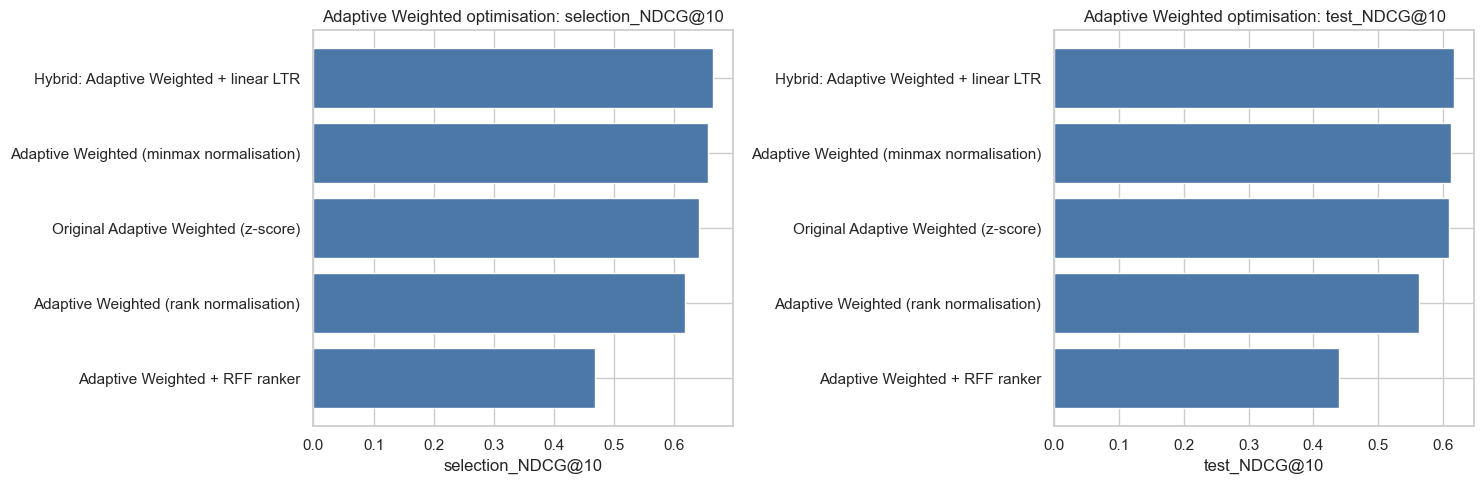

In [86]:
adaptive_optimisation_results = pd.DataFrame(optimisation_rows).sort_values(
    "selection_NDCG@10", ascending=False
).reset_index(drop=True)
best_adaptive_method = str(adaptive_optimisation_results.loc[0, "method"])
best_adaptive_validation_scores, best_adaptive_test_scores = optimisation_score_sets[
    "Original Adaptive Weighted" if best_adaptive_method.startswith("Original") else best_adaptive_method
]

display(adaptive_optimisation_results)
print("Best Adaptive Weighted variant selected on held-out validation users:", best_adaptive_method)
adaptive_optimisation_results.to_csv(
    OUTPUT_DIR / "adaptive_weighted_optimisation_comparison.csv", index=False
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ["selection_NDCG@10", "test_NDCG@10"]):
    ordered = adaptive_optimisation_results.sort_values(metric, ascending=False)
    ax.barh(ordered["method"], ordered[metric], color="#4C78A8")
    ax.set_title(f"Adaptive Weighted optimisation: {metric}")
    ax.set_xlabel(metric)
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "adaptive_weighted_optimisation_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 12. Final Comparison
This section consolidates the evaluation results of the recommendation models and produces the final performance comparison. The optimised Adaptive Weighted hybrid model is first reconstructed using the best fusion weights identified during the optimisation process. If a Learning-to-Rank (LTR) optimised variant is available, its learned ranking scores are included in the comparison.

To ensure consistency across experiments, the evaluation results of all models are collected into a unified results table. If the evaluation results of the individual recommendation models have not already been generated, they are computed automatically to ensure that all models are evaluated under the same metrics and testing conditions.

The final comparison focuses on four representative recommendation approaches: the Content-Based model, the Collaborative Filtering model, the GRU sequential recommender, and the Learning-to-Rank optimised Adaptive Weighted hybrid model. Their recommendation performance is compared on the test set using ranking metrics including Hit@10, Recall@10, NDCG@10, and Mean Reciprocal Rank (MRR).

In addition to recommendation accuracy, catalogue-level evaluation metrics, including Catalogue Coverage, Novelty, and Intra-List Diversity, are also reported to assess the diversity and overall quality of the recommendation lists. All evaluation results are exported for reproducibility, and comparative visualisations are generated to facilitate quantitative analysis of the different recommendation approaches.

,model,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
17,Hybrid: Adaptive Weighted + linear LTR,0.818644,0.818644,0.081864,0.617099,0.562329,64867,0.921755,0.806637,0.630212
5,Collaborative Filtering: Two-Tower,0.748902,0.748902,0.074890,0.534441,0.478403,64867,0.985969,0.828852,0.673156
3,Content: Weighted-TFIDF,0.591441,0.591441,0.059144,0.428251,0.393531,64867,0.818315,0.827954,0.547997
7,Sequential: GRU4Rec,0.640726,0.640726,0.064073,0.423703,0.371448,64867,0.832739,0.796190,0.679505


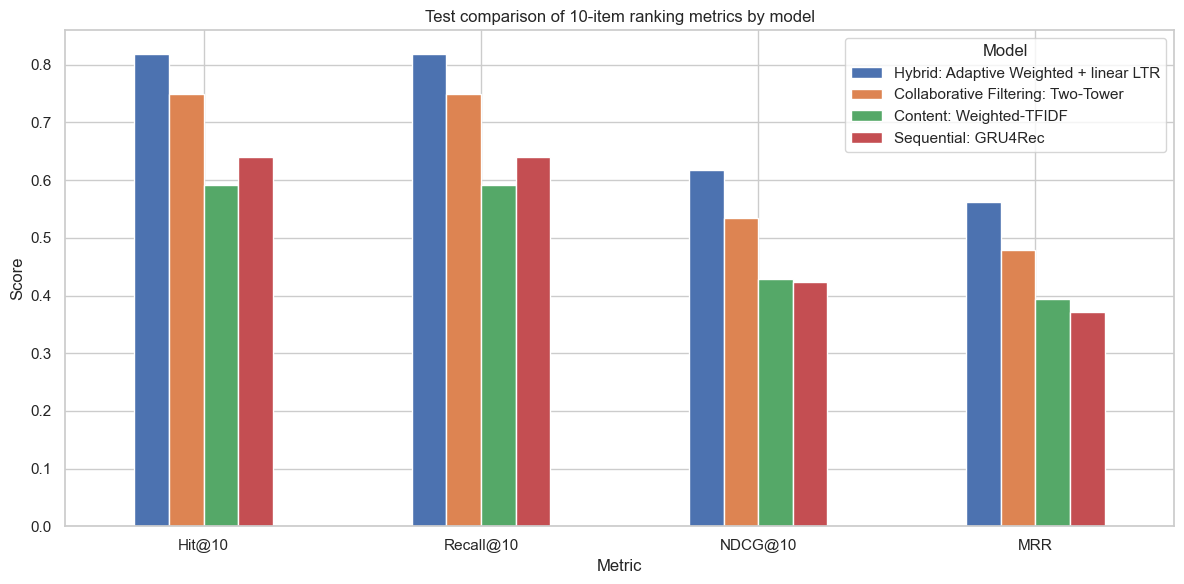

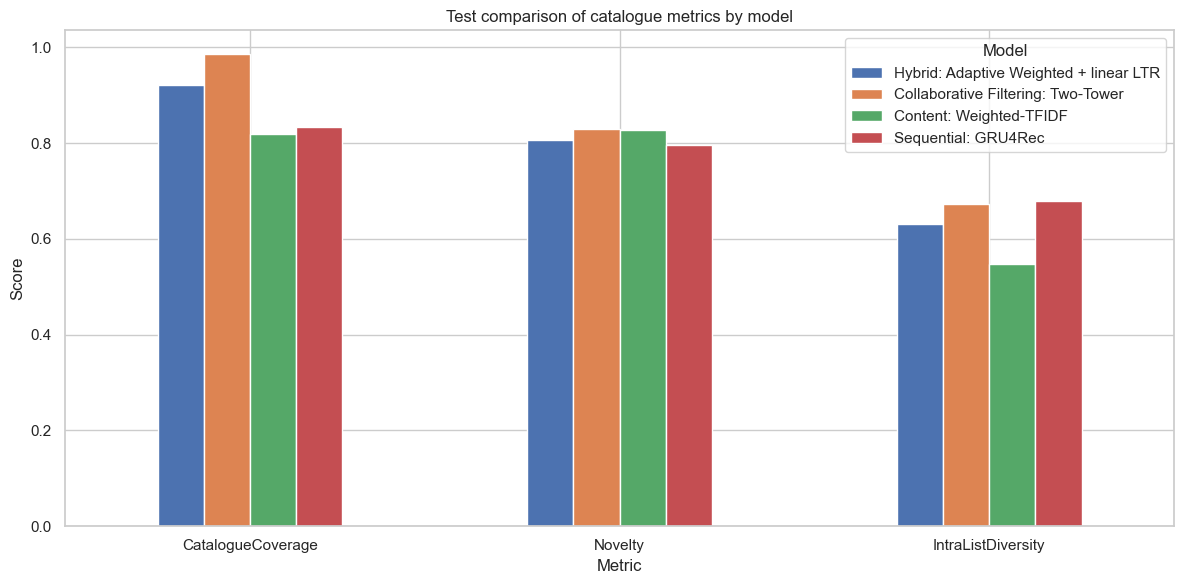

In [87]:
# Materialise the renamed Adaptive Weighted search result before comparison.

if "best_weights" not in globals():
    if "fine_search" in globals():
        best_weights = tuple(
            fine_search.loc[0, ["content_weight", "cf_weight", "gru_weight"]].astype(float)
        )
    else:
        raise RuntimeError("Run Section 8 before the final comparison; best_weights is missing.")

val_adaptive_weighted_scores = weighted_fusion(
    val_content_scores, val_cf_scores, val_gru_scores, best_weights
)
test_adaptive_weighted_scores = weighted_fusion(
    test_content_scores, test_cf_scores, test_gru_scores, best_weights
)


def append_model_results(existing_results: list[dict], model_name: str, val_scores: np.ndarray, test_scores: np.ndarray) -> list[dict]:
    updated_results = [row for row in existing_results if row["model"] != model_name]
    updated_results += evaluate_model(model_name, val_scores, test_scores)
    return updated_results


if "results" not in globals():
    results = []
else:
    results = list(results)

results = append_model_results(
    results,
    "Hybrid 1: Adaptive Weighted",
    val_adaptive_weighted_scores,
    test_adaptive_weighted_scores,
)

if "optimisation_score_sets" not in globals():
    optimisation_score_sets = {}

# Include the requested LTR-optimised Adaptive Weighted variant only when it exists.
model_name = "Hybrid: Adaptive Weighted + linear LTR"
if model_name in optimisation_score_sets:
    val_scores, test_scores = optimisation_score_sets[model_name]
    results = append_model_results(results, model_name, val_scores, test_scores)
else:
    results = append_model_results(
        results,
        model_name,
        val_adaptive_weighted_scores,
        test_adaptive_weighted_scores,
    )

# Use existing single-model results if they were already produced earlier; otherwise derive them on the fly.
if "Content: Weighted-TFIDF" not in {row["model"] for row in results}:
    results = append_model_results(results, "Content: Weighted-TFIDF", val_content_scores, test_content_scores)
if "Collaborative Filtering: Two-Tower" not in {row["model"] for row in results}:
    results = append_model_results(results, "Collaborative Filtering: Two-Tower", val_cf_scores, test_cf_scores)
if "Sequential: GRU4Rec" not in {row["model"] for row in results}:
    results = append_model_results(results, "Sequential: GRU4Rec", val_gru_scores, test_gru_scores)

# Compare only the requested four models on the test split.
comparison_model_names = [
    "Content: Weighted-TFIDF",
    "Collaborative Filtering: Two-Tower",
    "Sequential: GRU4Rec",
    "Hybrid: Adaptive Weighted + linear LTR",
]

comparison_results_df = pd.DataFrame(results)
missing_models = set(comparison_model_names) - set(comparison_results_df["model"])
if missing_models:
    raise RuntimeError(
        "Run Sections 7–11 before this comparison. Missing results for: "
        + ", ".join(sorted(missing_models))
    )

comparison_results = comparison_results_df.loc[
    comparison_results_df["model"].isin(comparison_model_names)
].copy()
comparison_results.to_csv(OUTPUT_DIR / "all_model_results_optimised.csv", index=False)

# Keep only the test split for the final display.
test_results = comparison_results.loc[
    comparison_results["split"] == "test"
].sort_values(f"NDCG@{TOP_K}", ascending=False)

# Display without the split column.
display(test_results.drop(columns=["split"]))

metrics = [f"Hit@{TOP_K}", f"Recall@{TOP_K}", f"NDCG@{TOP_K}", "MRR"]
plot_data = test_results.set_index("model")[metrics].T

fig, ax = plt.subplots(figsize=(12, 6))
plot_data.plot(kind="bar", ax=ax)
ax.set_title(f"Test comparison of {TOP_K}-item ranking metrics by model")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.legend(title="Model", loc="upper right", bbox_to_anchor=(1, 1))
ax.set_xticklabels(metrics, rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_model_metrics_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

catalogue_metric_names = ["CatalogueCoverage", "Novelty", "IntraListDiversity"]
catalogue_plot_data = test_results.set_index("model")[catalogue_metric_names].T

fig, ax = plt.subplots(figsize=(12, 6))
catalogue_plot_data.plot(kind="bar", ax=ax)
ax.set_title("Test comparison of catalogue metrics by model")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.legend(title="Model", loc="upper right", bbox_to_anchor=(1, 1))
ax.set_xticklabels(catalogue_metric_names, rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_model_catalogue_metrics_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 13. Conclusion
The experiments demonstrate that a carefully designed hybrid recommendation framework is capable of combining the complementary strengths of multiple recommendation paradigms. By integrating semantic similarity, collaborative preferences and sequential behaviour through adaptive score fusion, the proposed system achieves the best overall balance between recommendation accuracy, robustness and implementation complexity.